In [2]:
import numpy as _np
import matplotlib.pyplot as _plt
import h5py as _h5
import pickle as _pk

import os
import sys
parent_folder = os.path.abspath('..')
if parent_folder not in sys.path:
    sys.path.append(parent_folder)
import generatePtarmiganFiles

In [4]:
templatepath = "../../../clara-febe/03_ptarmigan/"
templatename = "clara_template.yml"
outputpath = "../../../clara-febe/03_ptarmigan/hdf5/"

In [ ]:
def GenRun(tagbase="CLARA_scan", seed=0, energy=350e6, a0=2, ngenerate=1000000, waist=5e-6, radius=5e-6, printPtarmigan=False):
    tag = "{}_{:.2e}_eV_a0_{}".format(tagbase, energy, a0)
    generatePtarmiganFiles.GeneratePtarmiganFile(tag=tag, seed=seed, ngenerate=ngenerate, E=energy, a0=a0, waist=waist, radius=radius,
                                                yml_path=outputpath, templatefilename=templatename, templatefolder=templatepath)
    generatePtarmiganFiles.RunPtarmiganFile(outputpath + tag + '.yml', printPtarmigan=printPtarmigan, removeYmlFile=True, mpi=True)

In [ ]:
for energy in [4e9]:
    for a0 in [40]:
        print(str(energy) + "  " + str(a0))
        GenRun(tagbase="CLARA_focused_scan", seed=0, energy=energy, a0=a0, ngenerate=1000000, printPtarmigan=True)

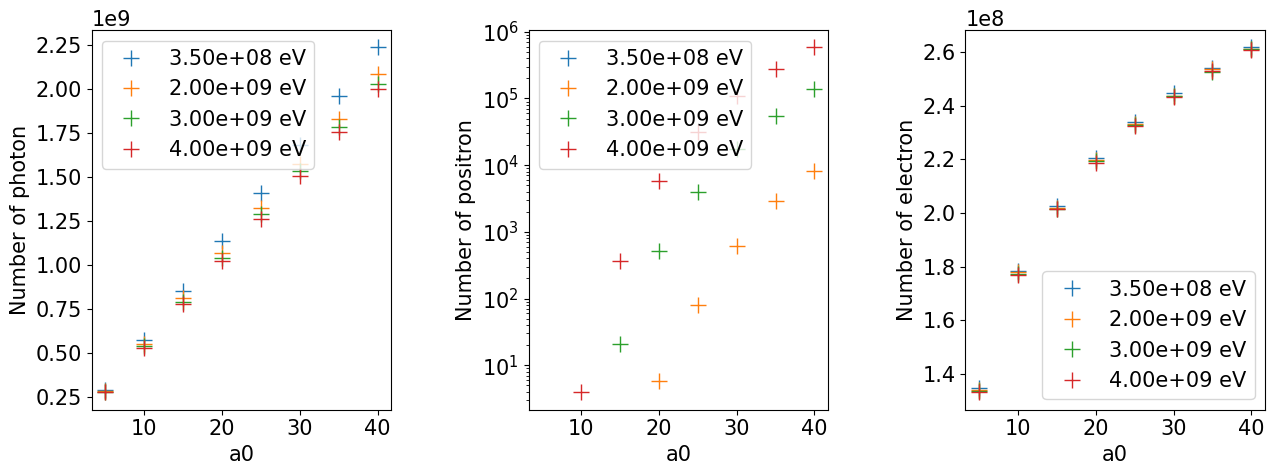

In [5]:
generatePtarmiganFiles.plotAllA0EnergyCurves(outputpath+"CLARA_scan*.h5", figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
axes[1].set_yscale('log')

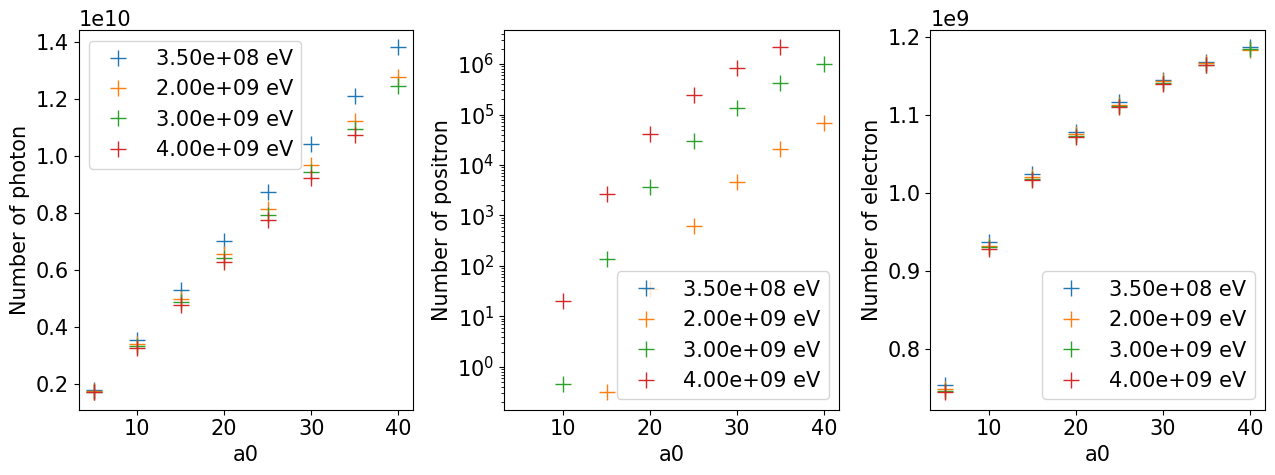

In [6]:
generatePtarmiganFiles.plotAllA0EnergyCurves(outputpath+"CLARA_focused_scan*.h5", figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
axes[1].set_yscale('log')

[]

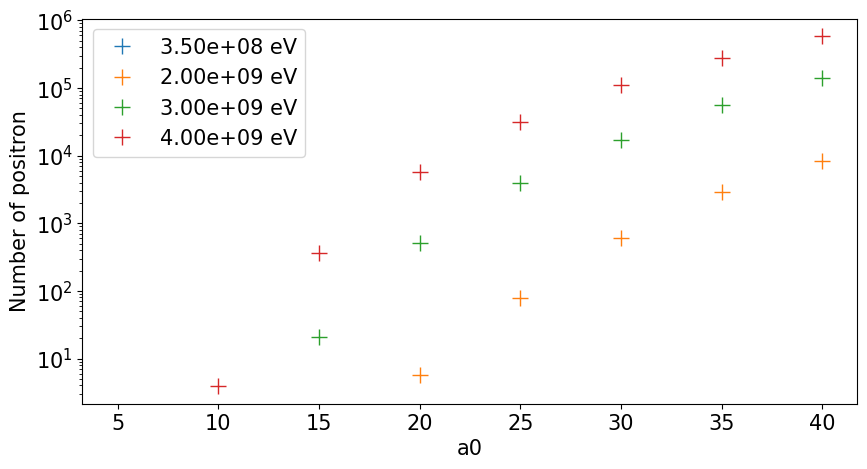

In [11]:
_plt.figure(figsize=[10, 5])
generatePtarmiganFiles.plotA0CurvesforEachEnergy(outputpath+"CLARA_scan*.h5", part='positron')
_plt.semilogy()

[]

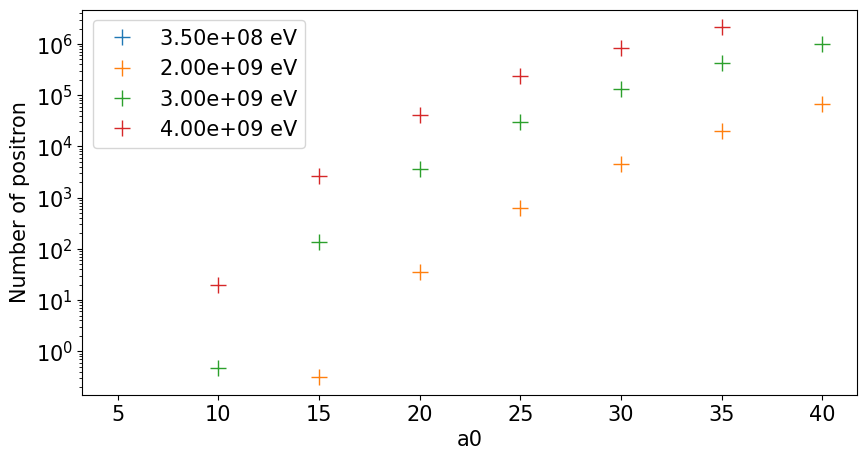

In [8]:
_plt.figure(figsize=[10, 5])
generatePtarmiganFiles.plotA0CurvesforEachEnergy(outputpath+"CLARA_focused_scan*.h5", part='positron')
_plt.semilogy()

In [21]:
generatePtarmiganFiles.getNumberParticlesWeighted(outputpath+"CLARA_focused_scan_2.00e+09_eV_a0_15_particles.h5", part='positron')

0.31207538243277744

In [96]:
ptarmiganfile1 = "../../00_ptarmigan/CLARA_350_MeV_100000_particles.h5"
ptarmiganfile2 = "../../00_ptarmigan/CLARA_2_GeV_100000_particles.h5"
ptarmiganfile3 = "../../00_ptarmigan/CLARA_5_GeV_100000_particles.h5"
ptarmiganfile4 = "../../00_ptarmigan/CLARA_10_GeV_100000_particles.h5"
ptarmiganfile5 = "../../00_ptarmigan/CLARA_5_GeV_10_a0_100000_particles.h5"
ptarmiganfile6 = "../../00_ptarmigan/CLARA_2_GeV_20_a0_100000_particles.h5"

In [97]:
file1 = _h5.File(ptarmiganfile1)
file2 = _h5.File(ptarmiganfile2)
file3 = _h5.File(ptarmiganfile3)
file4 = _h5.File(ptarmiganfile4)
file5 = _h5.File(ptarmiganfile5)
file6 = _h5.File(ptarmiganfile6)

In [98]:
E1_photon   = file1['final-state/photon/momentum'][:][:,0]
E2_photon   = file2['final-state/photon/momentum'][:][:,0]
E3_photon   = file3['final-state/photon/momentum'][:][:,0]
E4_photon   = file4['final-state/photon/momentum'][:][:,0]
E5_photon   = file5['final-state/photon/momentum'][:][:,0]
E6_photon   = file6['final-state/photon/momentum'][:][:,0]

E1_positron = file1['final-state/positron/momentum'][:][:,0]
E2_positron = file2['final-state/positron/momentum'][:][:,0]
E3_positron = file3['final-state/positron/momentum'][:][:,0]
E4_positron = file4['final-state/positron/momentum'][:][:,0]
E5_positron = file5['final-state/positron/momentum'][:][:,0]
E6_positron = file6['final-state/positron/momentum'][:][:,0]

E1_electron = file1['final-state/electron/momentum'][:][:,0]
E2_electron = file2['final-state/electron/momentum'][:][:,0]
E3_electron = file3['final-state/electron/momentum'][:][:,0]
E4_electron = file4['final-state/electron/momentum'][:][:,0]
E5_electron = file5['final-state/electron/momentum'][:][:,0]
E6_electron = file6['final-state/electron/momentum'][:][:,0]

W1_photon   = file1['final-state/photon/weight'][:]
W2_photon   = file2['final-state/photon/weight'][:]
W3_photon   = file3['final-state/photon/weight'][:]
W4_photon   = file4['final-state/photon/weight'][:]
W5_photon   = file5['final-state/photon/weight'][:]
W6_photon   = file6['final-state/photon/weight'][:]

W1_positron = file1['final-state/positron/weight'][:]
W2_positron = file2['final-state/positron/weight'][:]
W3_positron = file3['final-state/positron/weight'][:]
W4_positron = file4['final-state/positron/weight'][:]
W5_positron = file5['final-state/positron/weight'][:]
W6_positron = file6['final-state/positron/weight'][:]

W1_electron = file1['final-state/electron/weight'][:]
W2_electron = file2['final-state/electron/weight'][:]
W3_electron = file3['final-state/electron/weight'][:]
W4_electron = file4['final-state/electron/weight'][:]
W5_electron = file5['final-state/electron/weight'][:]
W6_electron = file6['final-state/electron/weight'][:]

[]

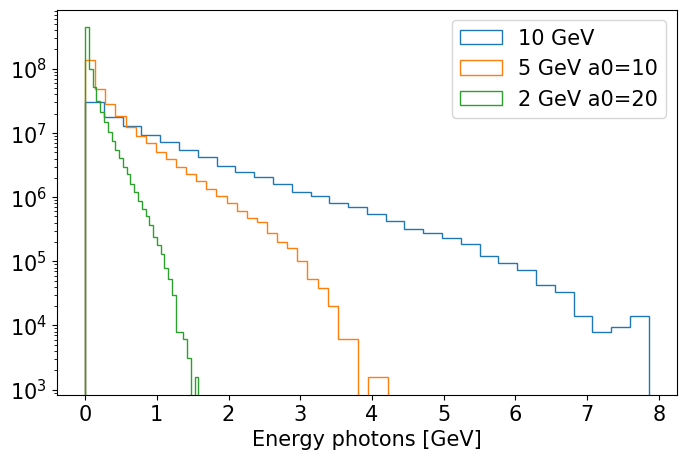

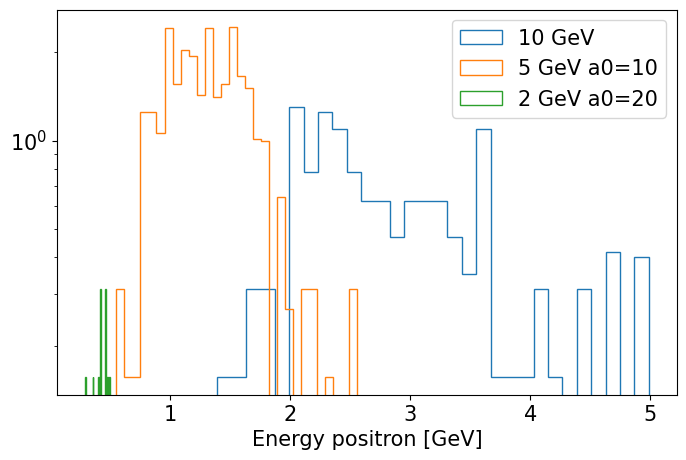

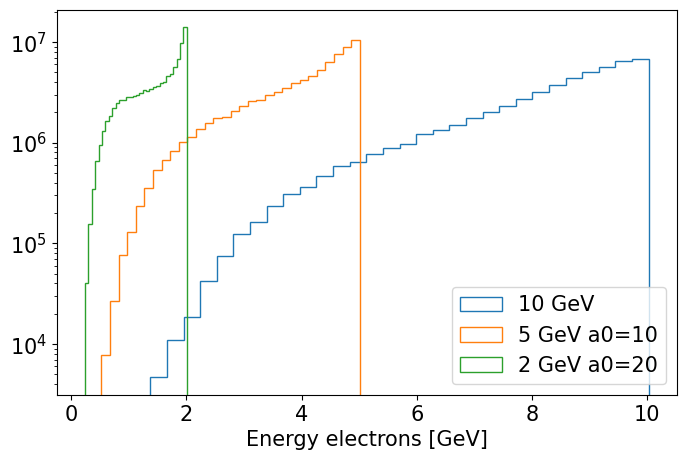

In [99]:
nbins=30

_plt.rcParams['font.size'] = 15
_plt.figure(figsize=[8, 5])
_plt.hist(E4_photon, weights=W4_photon, color='C0', label='10 GeV', bins=nbins, histtype='step')
_plt.hist(E5_photon, weights=W5_photon, color='C1', label='5 GeV a0=10', bins=nbins, histtype='step')
_plt.hist(E6_photon, weights=W6_photon, color='C2', label='2 GeV a0=20', bins=nbins, histtype='step')
_plt.xlabel('Energy photons [GeV]')
_plt.legend()
_plt.semilogy()

_plt.figure(figsize=[8, 5])
_plt.hist(E4_positron, weights=W4_positron, color='C0', label='10 GeV', bins=nbins, histtype='step')
_plt.hist(E5_positron, weights=W5_positron, color='C1', label='5 GeV a0=10', bins=nbins, histtype='step')
_plt.hist(E6_positron, weights=W6_positron, color='C2', label='2 GeV a0=20', bins=nbins, histtype='step')
_plt.xlabel('Energy positron [GeV]')
_plt.legend()
_plt.semilogy()

_plt.figure(figsize=[8, 5])
_plt.hist(E4_electron, weights=W4_electron, color='C0', label='10 GeV', bins=nbins, histtype='step')
_plt.hist(E5_electron, weights=W5_electron, color='C1', label='5 GeV a0=10', bins=nbins, histtype='step')
_plt.hist(E6_electron, weights=W6_electron, color='C2', label='2 GeV a0=20', bins=nbins, histtype='step')
_plt.xlabel('Energy electrons [GeV]')
_plt.legend()
_plt.semilogy()